In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
merged_ground_truth_sentences = [
    'god gives birth life to people in town',
    'king holds power above city and people great',
    'mother love life and peace for people town',
    'man hears god voice in temple great peace',
    'woman sees star above river at night sky',
    'father gives bread offering to god great temple',
    'scribe writes book in temple for king great',
    'people gather at riverbank near town great peace',
    'god becomes scarab and rises from water life',
    'king sits on throne with power great strength',
    'woman brings offering to temple for god peace',
    'people see horizon above desert hill sky great',
    'man opens door and enters house safely peace',
    'god grants life strength and stability to king',
    'people honor god in temple with offering peace',
    'seated god rules sky with great power',
    'old man speaks wisdom before people peacefully',
    'cobra guards temple gate at desert night',
    'scribe hears king command and writes carefully',
    'mother gives milk jar to youth gently',
    'river flows behind town under bright sky',
    'god sees heart of man with truth',
    'people offer bread and lotus to deity',
    'king emerges from palace with great authority',
    'woman walks road beside riverbank calmly',
    'man fears storm above mountain at night',
    'temple stands firm with stability and power',
    'god grants peace life and strength forever',
    'people gather before throne to hear king',
    'scribe reads scroll inside house quietly',
    'youth drinks water beside lake under sky',
    'god opens horizon and emerges with light',
    'woman carries basket with handle to house',
    'man plows field with hoe and strength',
    'people cross river by road near town',
    'king hears servant speak inside great temple',
    'mother sees child become strong and healthy',
    'god dwells underground and rises at dawn',
    'scribe sits on stool writing sacred words',
    'man eats bread and drinks water peacefully',
    'people fear snake near riverbank at night',
    'woman opens gate and enters town calmly',
    'god places feather of truth upon heart',
    'king stands firm like pillar of stability',
    'people celebrate life under stars and sky',
    'seated woman hears owl call at night sky',
    'king gives offering bread to temple god great',
    'scribe walks road beyond town toward horizon slowly',
    'man carries rope across desert hill alone calmly',
    'people see scarab become life from water ripple',
    'god rests on throne inside sacred temple quietly',
    'woman fills jar with milk for child gently',
    'king commands servant to open gate now quickly',
    'old man sits beside lake remembering youth quietly',
    'people plant grain in field before flood season',
    'god lifts sky above mountain with strength great',
    'scribe studies papyrus scroll by fire light calmly',
    'youth follows road toward west under evening sky',
    'woman hears river ripple behind house at dawn',
    'man lifts stone with strength beside temple gate',
    'people sit on stool sharing bread peacefully together',
    'god sends star above horizon bringing life people',
    'scribe carries papyrus scroll into town carefully today',
    'king places crown upon head with authority great',
    'mother walks field gathering grain for household food',
    'man sees snake coil near riverbank cautiously today',
    'people honor ancestors pillar with offerings yearly together',
    'god grants heart peace strength and stability eternal',
    'woman opens door bolt before entering house quietly',
    'youth sits by lake watching stars above quietly',
    'man carries basket of grain into town slowly',
    'woman follows riverbank road toward west calmly',
    'god breathes life into clay vessel gently',
    'scribe sharpens chisel beside stone block carefully',
    'people gather under sky after storm peacefully',
    'king raises hand granting mercy to people',
    'mother stands at gate awaiting child return',
    'man hears owl behind house at night',
    'god places crown of power upon king',
    'people drink water near reed shelter together',
    'woman walks field holding lotus plant softly',
    'scribe records offerings on papyrus scroll inside temple',
    'king travels road beyond town toward western horizon',
    'woman pours water ripple into clay jar gently',
    'man shelters beneath reed hut during desert storm',
    'god watches people from sky with calm authority',
    'mother braids flax rope beside house doorway quietly',
    'people cross gate at dawn seeking peace together',
    'youth listens to father speak by fire calmly',
    'king inspects field before flood season begins yearly',
    'scribe teaches writing to youth inside town house',
    'woman places lotus offering upon altar peacefully today',
    'god strengthens backbone of king with power great',
    'man cuts reed leaf beside riverbank carefully',
    'woman carries water jar across town road slowly',
    'people rest on mats inside house after work',
    'god emerges at horizon bringing light and life',
    'scribe listens and writes words of authority faithfully',
    'king sits upon throne judging people with fairness',
    'mother teaches youth love peace and respect daily',
    'man plows hill slope field with steady strength',
    'people see swallow great flying above town sky',
    'god guards west gate of underground realm silently',
    'woman grinds grain into bread for offering today',
    'youth follows father into temple with reverence',
    'scribe lights fire inside temple before dawn',
    'king walks beside river reflecting on authority',
    'woman listens quietly as god speaks truth',
    'people gather grain from field after harvest',
    'man lifts door bolt to open gate',
    'mother rests on mat holding sleeping child',
    'god places soul within body granting life',
    'youth watches horizon as sun begins rise',
    'people follow king across desert road together',
    'scribe washes hands with water before writing',
    'man ties tethering rope around vessel securely',
    'woman stands beneath star filled night sky',
    'man sharpens adze beside stone block quietly today',
    'woman places bread loaf upon altar offering peacefully',
    'people hear king speak from throne calmly today',
    'scribe carries senet board into house carefully inside',
    'god lifts mountain above desert with strength great',
    'youth drinks milk from jar beside mother quietly',
    'man sees cobra crossing road near town suddenly',
    'people plant lotus near lake before sunrise together',
    'king gives command and servant listens respectfully closely',
    'woman opens papyrus scroll and reads slowly inside',
    'god grants stability djed to throne eternally strongly',
    'people walk toward gate under morning sky peacefully',
    'the great god gives life to the man',
    'the seated king sees the beautiful city town',
    'a scribe with a book hears the people',
    'the master of the house sees the heart',
    'a father gives a loaf of bread now',
    'the lord of all souls sees the sky',
    'a woman hears the god in the temple',
    'the great king sits upon the stone throne',
    'a servant plows the field near the river',
    'the spirit ka emerges from the mountain side',
    'a powerful cobra sits above the gate door',
    'the mother gives birth to a beautiful youth',
    'a man sees the star in the sky',
    'the old man hears the sound of water',
    'a soul becomes a star in the horizon',
    'the scribe writes a book about the truth',
    'the great god sees the heart of man',
    'a king gives a thousand jars of milk',
    'the servant brings a basket to the lord',
    'a desert hare sits behind the hill slope',
    'the master of the house gives an offering',
    'a great snake emerges from the underground place',
    'the woman sees a lotus plant in water',
    'a scribe hears the voice of the king',
    'the spirit ka finds peace in the temple',
    'a man with a club walks the road',
    'the great lord sees the soul of people',
    'a king gives power to the great city',
    'the scribe sees the truth in the book',
    'a god gives life to the beautiful woman',
    'the man with an adze cuts the wood',
    'a basket with handle sits on the brick',
    'the great power of the sky becomes fire',
    'a servant carries a jar to the master',
    'the heart of the king finds great peace',
    'a man plows the field with a hoe',
    'the soul of a man becomes a bird',
    'a scribe with a papyrus scroll sees truth',
    'the lord gives a loaf to the servant',
    'a cobra sits upon a coil of rope',
    'the gate to the city is made stone',
    'a youth sees the desert hill from afar',
    'the woman with a mirror sees her face',
    'a king with a club leads the people',
    'the master of the house eats the bread',
    'a star emerges above the great mountain peak',
    'the scribe makes a writing for the god',
    'a man finds a jar in the sand',
    'the great river flows to the west side',
    'a father gives a ring to his youth',
    'the servant with a basket walks the road',
    'a king sits on the throne of power',
    'the god gives a thousand offerings of grain',
    'a woman brings a lotus to the altar',
    'the old man hears the sound of wind',
    'a scribe reads the book in the temple',
    'the spirit ka enters the house of life',
    'a man cuts the papyrus with a sickle',
    'the lord of the field sees the grain',
    'a beautiful bird flies above the green lake',
    'the adze of the scribe sits on brick',
    'a coil of rope lies behind the basket',
    'the great storm emerges from the west sky',
    'a servant gives a conical loaf of bread',
    'the heart of a man becomes very sweet',
    'a bird head sits above the temple gate',
    'the lord of the house sees the field',
    'a thousand jars of grain sit in rows',
    'the spirit ka enters the body of man',
    'a man with a sickle cuts the plant',
    'the beautiful face of the woman is great',
    'a king finds peace upon the stone throne',
    'the riverbank is a place for the youth',
    'a scribe writes truth on the papyrus scroll',
    'the god gives authority to the great king',
    'a desert hill sits behind the city town',
    'the master of all people hears the plea',
    'a snake crawls under the gate of stone',
    'the soul of the father becomes a star',
    'a woman brings a milk jar to temple',
    'the backbone of the man is very strong',
    'a lion animal belly is on the ground',
    'the old man walks the road to peace',
    'a star shines above the great desert mountain',
    'the king gives a ring to the servant',
    'a lotus plant grows in the river water',
    'the scribe hears the heart of the people',
    'a reed shelter sits on the river bank',
    'the power of the god is very great',
    'a man with a club protects the house',
    'the scribe plays a game of senet board',
    'a chisel is used to cut the stone',
    'the tethering rope holds the boat at river',
    'a king with authority sees the great sky',
    'the venerated marrow is the life of man',
    'a woman sees her reflection in the water',
    'the placenta is a sign of new life',
    'a great storm moves across the desert hill',
    'the master of all things gives an offering',
    'a bird head is on the temple wall',
    'the servant brings a milk jar for king',
    'a man with a club walks behind town',
    'the star shines above the mountain of fire',
    'a soul becomes a bird in the afterlife',
    'the scribe reads the papyrus scroll for all',
    'a lotus plant grows near the reed shelter',
    'a youth finds a ring in the sand',
    'the heart of a god is very great',
    'a king gives a thousand jars of grain',
    'the old man finds peace in the city',
    'a snake crawls near the door bolt lock',
    'the father gives a book to the youth',
    'a beautiful face is seen in the temple',
    'the spirit ka finds the way to sky',
    'a man plows the field with great strength',
    'the mother gives birth to a strong son',
    'a star is above the house of life',
    'the great king sits upon the throne chair',
    'a servant carries the basket with a handle',
    'a man with three fox skins finds peace',
    'the swallow flies great distances over the river',
    'a folded cloth lies on the stone seat',
    'the scribe uses an adze for the wood',
    'a thousand people walk to the great city',
    'the god gives a heart to the man',
    'a beautiful lotus plant grows in the lake',
    'the master of the house sees the basket',
    'a king sits behind the great temple gate',
    'the spirit ka becomes a bird of fire',
    'a father gives a book to the mother',
    'the desert hare runs across the hill slope',
    'a servant carries a jar of sweet milk',
    'the authority of the king is very great',
    'a snake moves under the thick papyrus clump',
    'the youth finds a star in the water',
    'a man plows with the strength of god',
    'the sky becomes red above the desert hill',
    'a scribe writes on a single stroke papyrus',
    'the heart of the old man is happy',
    'a soul finds the way to the west',
    'the lord of all things sees the truth',
    'a woman with a basket walks the road',
    'the great power of the sun gives life',
    'a king gives a ring to the scribe',
    'the backbone of the snake is very long',
    'a youth hears the voice of the father',
    'the bird head sits on the brick wall',
    'a man finds a stone in the field',
    'the great city town is near the river',
    'a quail chick sits inside the reed shelter',
    'the scribe places the jars in a rack',
    'a strong door bolt secures the temple gate',
    'the great swallow flies above the river bank',
    'a man finds the three fox skins today',
    'the master of all souls sees the truth',
    'a woman with a basket hears the god',
    'the desert hill slope is very far away',
    'a servant gives a conical loaf to father',
    'the star shines above the house of gold',
    'the spirit ka becomes a great power now',
    'a youth sees the eye of the god',
    'the old man sits upon the stone mat',
    'a cobra moves behind the large clay brick',
    'the scribe makes a writing about the heart',
    'a thousand fish swim in the blue lake',
    'the backbone of the king is very strong',
    'a lotus plant grows near the papyrus clump',
    'the lord of the field finds a stone',
    'a soul becomes a bird in the sky',
    'the beautiful face of a woman gives peace',
    'a father gives a ring to the youth',
    'the great storm moves over the desert town',
    'a man with an adze cuts the wood',
    'the heart of a scribe is very sweet',
    'the light of the sun becomes the fire',
    'a woman hears the voice of the mother',
    'the great king sits upon the throne seat',
    'the man will eat and drink with king',
    'a scribe speaks the truth to the people',
    'the master plays on the great senet board',
    'a milk jar sits on the stone brick',
    'the spirit ka enters through the temple gate',
    'a man with a chisel cuts the side',
    'the great power of life is in god',
    'a woman with a basket walks to town',
    'the old man sees the heart of youth',
    'a thousand stars shine above the desert hill',
    'the lord of the house finds great peace',
    'a servant gives grain to the quail chick',
    'the backbone of the soul is the truth',
    'a scribe writes on the white papyrus scroll',
    'the father gives a conical loaf to child',
    'a cobra sits behind the door bolt lock',
    'the swallow flies to the great river bank',
    'a lotus plant grows in the lake water',
    'the king gives authority to the seated man',
    'a desert hare hides behind the hill slope',
    'the heart of a woman is very beautiful',
    'the great fire burns in the reed shelter',
    'a youth hears the word of the mother',
    'the throne of the king is made stone',
    'a soul becomes a bird in the horizon',
    'the master of all things sees the field',
    'a star is above the great mountain peak',
    'the head of bird sits on the basket',
    'a man with a hoe tilled the field',
    'the tethering rope is near the river water',
    'a scribe writes truth for the seated king',
    'the heart of a mother is very good',
    'a thousand bricks build the great city town',
    'the spirit ka finds peace in the sky',
    'a youth sees the cobra in the desert',
    'the master of the house eats a loaf',
    'a servant gives milk to the old man',
    'the backbone of the fish is on stone',
    'a star emerges above the dark mountain side',
    'the father gives a book to the scribe',
    'a woman with a mirror sees her face',
    'the great power of god is in truth',
    'a king sits upon the seat of authority',
    'the lotus plant opens in the morning light',
    'the scribe hears the voice of the people',
    'a thousand jars of grain are in store',
    'the lord of all things sees the heart',
    'a man with an adze makes the chair',
    'the swallow flies over the high temple gate',
    'a desert hare hides in the reed shelter',
    'the heart of the king is very strong',
    'a woman brings a jar to the altar',
    'the great storm moves across the west sky',
    'a scribe uses a chisel on the brick',
    'the animal belly is on the cold stone',
    'a scribe puts the jars in a rack',
    'the placenta is a sign of great birth',
    'a man sees the side rib of ox',
    'the venerated marrow gives life to the bone',
    'a bird head sits above the temple door',
    'the master of the house speaks with authority',
    'a thousand fish swim in the great river',
    'the spirit ka exists in the house life',
    'a youth finds a pearl in the lake',
    'the cobra moves behind the large clay brick',
    'a woman hears the voice of the god',
    'the great storm emerges from the east sky',
    'a king gives a thousand fields of grain',
    'the backbone of a man is very straight',
    'a scribe reads the book of the dead',
    'the heart of the king finds sweet peace',
    'a servant carries a basket with a handle',
    'the desert hare runs to the reed shelter',
    'a man with a hoe tilled the ground',
    'the star is above the mountain of fire',
    'a father gives a ring to his daughter',
    'the old man sees the truth in life',
    'a soul becomes a star in the sky',
    'the great power of the sun gives warmth',
    'the lord of all things sees the world',
    'a swallow flies over the high city wall',
    'the scribe uses an adze on the wood',
    'a youth hears the heart of the father',
    'the head of ox sits on the altar',
    'a scribe plays senet board with the king',
    'the master of all people sees the truth',
    'a servant gives a conical loaf to mother',
    'the heart of a man finds great content',
    'a beautiful lotus plant grows in the river',
    'the spirit ka enters the body of woman',
    'a youth finds a stone in the desert',
    'the old man speaks with the great god',
    'a star is above the house of peace',
    'the backbone of the fish is very long',
    'a cobra hides behind the large stone brick',
    'the great power of the sun gives light',
    'the scribe writes on a white papyrus scroll',
    'the lord of the house finds sweet peace',
    'a thousand jars of grain are for king',
    'the soul of a man becomes a star',
    'a swallow flies over the high temple gate',
    'the father gives a ring to the youth',
    'a great storm moves across the west mountain',
    'the great city town is near the water',
    'a man finds three fox skins in desert',
    'the goddess gives birth to a beautiful child',
    'a thousand stars shine in the night sky',
    'the seated god sees the heart of man',
    'a master of all things gives the power',
    'the scribe finds a book in the house',
    'a great fire burns near the reed shelter',
    'the stone brick is for the city wall',
    'a woman with a mirror sees the truth',
    'the spirit ka exists within the great temple',
    'a youth plays a game of senet board',
    'the cobra moves through the thick papyrus clump',
    'a man with a chisel makes the throne',
    'the great storm moves over the river bank',
    'a servant gives a milk jar to god',
    'the backbone of the father is very strong',
    'the king gives a ring to the woman',
    'a swallow flies to the house of peace',
    'the heart of the king is very good',
    'a youth finds a stone near the gate',
    'the scribe uses an adze for the chair',
    'the mother gives birth to a beautiful son',
    'the lord of the house finds sweet milk',
    'a star is above the great mountain side',
    'the great power of life is in truth',
    'the desert hare hides in the green field',
    'a king sits upon the throne of stone',
    'the jars in rack are for the king',
    'a man does not fear the great storm',
    'the animal belly is near the river bank',
    'a scribe speaks with the power of truth',
    'the master of the house satisfies the guest',
    'the side rib of the ox is good',
    'a youth finds the door bolt in sand',
    'the heart of the mother is very beautiful',
    'a thousand fish emerge from the deep lake',
    'the great king sees the field of grain',
    'a servant brings a milk jar for altar',
    'the backbone of the scribe is very straight',
    'the old man hears the voice of god',
    'the father gives a conical loaf to son',
    'a swallow flies over the high city town',
    'the great power of the sun gives fire',
    'the lotus plant opens in the morning water',
    'the mother gives birth to a strong youth',
    'a beautiful bird flies above the desert hill',
    'the twisted flax is used for the rope',
    'a quail chick hides in the papyrus clump',
    'the scribe marks a single stroke on stone',
    'a man finds the venerated marrow of life',
    'the great lord does not fear the snake',
    'a woman with a basket sees the gate',
    'the spirit ka finds content in the temple',
    'a king with authority speaks to the people',
    'the backbone of a man is his strength',
    'a thousand stars shine above the river bank',
    'the heart of a youth is very sweet',
    'a servant carries grain to the city town',
    'the lotus plant grows near the water ripple',
    'a cobra sits behind the large door bolt',
    'a star emerges from the great night sky',
    'the scribe reads the book of the father',
    'a woman hears the bird in the tree',
    'the great power of god makes the world',
    'the mother gives birth to a beautiful daughter',
    'a swallow flies over the high mountain peak',
    'a king sits upon the throne of gold',
    'a thousand jars of milk are for king',
    'a youth finds a ring in the field',
    'the great storm moves over the desert land',
    'a scribe writes truth with a reed pen',
    'the head of bird sits on a basket',
    'a horned viper crawls near the stone brick',
    'the jars in rack are for the master',
    'a man sits upon the stool mat today',
    'the great sky becomes fire above the mountain',
    'the spirit ka finds peace in the house',
    'a thousand stars shine over the city town',
    'a king with authority sees the great field',
    'the backbone of a man is very great',
    'a servant carries a milk jar to temple',
    'the heart of the goddess is very sweet',
    'a swallow flies above the high river bank',
    'the lord of all things finds great content',
    'a youth finds a ring in the desert',
    'the old man speaks to the seated god',
    'a cobra hides behind the large door bolt',
    'a woman with a basket hears the voice',
    'the great storm moves across the west hill',
    'a scribe uses a chisel on the stone',
    'a beautiful face is seen in the water',
    'the man with three fox skins finds peace',
    'a scribe sits upon the stool mat today',
    'the water ripple moves near the river bank',
    'a king plays on the great senet board',
    'the spirit ka emerges from the temple gate',
    'a woman with a basket hears the truth',
    'the master of the house sees the field',
    'a thousand stars shine above the great desert',
    'a star becomes a god in the sky',
    'a servant carries a milk jar for altar',
    'the heart of a man is very sweet',
    'the lord of all souls finds great content',
    'a youth finds a stone in the lake',
    'the old man speaks to the seated king',
    'a cobra hides behind the large clay brick',
    'the scribe uses an adze for the boat',
    'a thousand jars of grain are for god',
    'a woman with a mirror sees the face',
    'a man with a hoe tilled the earth',
    'a father gives a ring to the daughter',
    'a scribe uses a chisel on the wall',
    'the desert hare runs to the green plant',
    'a beautiful bird sits on the reed shelter',
    'the scribe marks a single stroke on papyrus',
    'a man binds the twisted flax into rope',
    'the animal belly is seen on the stone',
    'a thousand people find peace in the city',
    'the venerated marrow is the strength of man',
    'a woman with a basket hears the bird',
    'a king with authority speaks to the god',
    'a star emerges above the high mountain side',
    'the heart of a youth is very good',
    'a servant carries grain to the great lord',
    'the lotus plant grows in the water ripple',
    'a swallow flies from the great desert hill',
    'the scribe reads the book for the people',
    'the great power of life gives the light',
    'the desert hare hides in the reed shelter',
    'a king sits upon the throne of power',
    'the old man finds peace in the temple',
    'the quail chick hides inside the reed shelter',
    'a man finds twisted flax near the river',
    'the animal belly is cold on the stone',
    'a scribe plays a game of senet board',
    'the master of the house goes back home',
    'a thousand stars shine in the underground place',
    'the spirit ka enters through the temple door',
    'a youth sees the cobra behind the wall',
    'the old man sits upon the stool mat',
    'a star becomes a god in the horizon',
    'a servant carries a milk jar for king',
    'the heart of a woman is very sweet',
    'a swallow flies above the high city town',
    'the scribe speaks to the seated king today',
    'the horned viper crawls near the stone brick',
    'a man binds the tethering rope to boat',
    'the spirit ka exists in the great temple',
    'the master of the house speaks the truth',
    'a star shines above the house of life',
    'the lord of all things gives the power',
    'the great storm moves over the desert hill',
    'a father gives a ring to the son',
    'a man with authority sees the beautiful sky',
    'the quail chick sits on the stone brick',
    'a scribe makes the writing about the heart',
    'the twisted flax becomes a strong tethering rope',
    'a thousand people find the way to peace',
    'a servant carries the jars in a rack',
    'the backbone of the god is the truth',
    'a star shines above the great city town',
    'the spirit ka finds life in the temple',
    'a youth sees the swallow in the sky',
    'the old man speaks with the seated king',
    'a cobra moves under the large door bolt',
    'the scribe uses a chisel on the throne',
    'a thousand jars of milk are for god',
    'the heart of a woman is very good',
    'the lotus plant grows in the river bank',
    'a father gives a conical loaf to child',
    'the great power of life is in man',
    'a king sits upon the seat of stone',
    'a scribe uses an adze for the boat',
    'a beautiful bird sits on the papyrus clump',
    'a man with authority protects the great city',
    'the animal belly is on the warm stone',
    'a servant brings the jars in a rack',
    'the master of the house speaks to people',
    'a scribe finds the truth in the book',
    'the heart of a mother is very sweet',
    'a king sits upon the seat of power',
    'the old man walks to the temple gate',
    'the father gives a conical loaf to youth',
    'a man with a hoe plows the field',
    'the lord of all things finds sweet peace',
    'the scribe uses a chisel on the stone',
    'a man binds the twisted flax for rope',
    'the master of all every sees the truth',
    'a woman hears the bird in the field',
    'a servant carries grain to the city gate',
    'the lotus plant grows in the lake water',
    'the backbone of the father is his strength',
    'a bird head is on the stone wall',
    'the horned viper hides in the stone wall',
    'a steward brings the jars in a rack',
    'the side rib of ox is on altar',
    'a man with authority leads the city people',
    'the great senet board sits on the stool',
    'a scribe finds the heart of the truth',
    'the spirit ka remains in the house life',
    'a thousand fish swim in the blue water',
    'the mother gives birth to a strong daughter',
    'a king sits upon the seat of gold',
    'the backbone of the bird is very small',
    'the old man speaks to the great goddess',
    'a cobra moves behind the large door bolt',
    'a lotus plant grows in the river bank',
    'the animal belly is on the warm sand',
    'a star is above the great temple gate',
    'the quail chick finds grain in the field',
    'a scribe binds the twisted flax for god',
    'the placenta is placed on the stone altar',
    'a man smells the lotus in the water',
    'the spirit ka moves between the house walls',
    'the master of the house gives sweet milk',
    'a youth sees the cobra under the brick',
    'the old man hears the voice of truth',
    'a star emerges above the high city gate',
    'the backbone of the ox is very large',
    'a servant carries a basket to the queen',
    'the heart of a child is very good',
    'a swallow flies over the green papyrus clump',
    'a youth finds a ring in the lake',
    'the scribe speaks the word of the king',
    'the great storm moves over the mountain peak',
    'a thousand jars of grain are for people',
    'a beautiful bird sits on the temple wall',
    'the man with authority finds the stone brick',
    'a scribe uses a chisel for the heart',
    'the side rib of animal sits on stone',
    'a servant carries grain to the reed shelter',
    'the venerated marrow is found in the bone',
    'a thousand stars shine above the house gold',
    'a youth sees the eye of the bird',
    'the old man speaks with the great master',
    'a star is above the high temple gate',
    'the backbone of the fish is on altar',
    'the father gives a conical loaf to mother',
    'the mother gives birth to a beautiful child',
    'the desert hare hides in the green plant',
    'the animal belly is cold on the sand',
    'a beautiful bird sits on the city wall',
    'the king sits upon the seat of gold',
    'a servant gives a jar to the goddess',
    'a man binds the tethering rope to stone',
    'the quail chick sits inside the papyrus clump',
    'a thousand fish swim in the river ripple',
    'a woman with a basket walks to gate',
    'a youth sees the cobra in the sand',
    'a scribe uses an adze for the wood',
    'the man binds the twisted flax for rope',
    'a scribe marks a single stroke on wood',
    'the venerated marrow is inside the large bone',
    'a thousand bricks build the house of life',
    'a star emerges above the high desert hill',
    'a swallow flies from the green papyrus clump',
    'the scribe reads the book for the mother',
    'a woman hears the voice of the king',
    'a man with an adze makes the stool',
    'a thousand jars of milk are for queen',
    'a side rib of ox is for god',
    'the master of the house finds a stool',
    'a youth plays with the jars in rack',
    'the spirit ka finds the path to sky',
    'a woman with a basket sees the field',
    'the great power of truth is in god',
    'a star emerges above the high city town',
    'the backbone of the mother is very strong',
    'the heart of a father is very good',
    'a swallow flies over the green reed shelter',
    'a thousand bricks build the wall of city',
    'the desert hare hides in the papyrus clump',
    'a scribe uses a chisel on the throne',
    'a beautiful bird sits on the temple gate',
    'the horned viper moves through the green field',
    'a quail chick sits near the water ripple',
    'the door bolt is for the city gate',
    'a man with authority protects the temple house',
    'the old man speaks to the great master',
    'a thousand bricks build the wall of house',
    'the lord of all souls finds sweet peace',
    'the master of truth finds the heart good',
    'a scribe puts the vessel in a rack',
    'a man sits upon the small stool mat',
    'the venerated man finds peace in the city',
    'a scribe marks every single stroke on stone',
    'the animal belly remains on the warm brick',
    'a youth plays on the great senet board',
    'the master of all things is very content',
    'a servant carries the vessel in a rack',
    'the spirit ka exists within the stone wall',
    'a thousand stars shine in the great sky',
    'a star emerges from the high desert hill',
    'a swallow flies to the green papyrus clump',
    'a lotus plant opens in the morning light',
    'the great storm moves across the west land',
]

In [3]:
shuffled_sentences_raw = [
    "life\nto\nin\ntown\nbirth\npeople\ngod\ngives",
    "above\ngreat\npower\nking\ncity\npeople\nand\nholds",
    "and\nfor\nlife\npeace\nlove\npeople\ntown\nmother",
    "god\nhears\nman\npeace\nin\ngreat\ntemple\nvoice",
    "at\nstar\nsky\nabove\nsees\nwoman\nnight\nriver",
    "god\noffering\ngreat\nto\nfather\ntemple\ngives\nbread",
    "in\nwrites\nscribe\ngreat\ntemple\nbook\nking\nfor",
    "town\npeace\ngreat\nat\nnear\npeople\nriverbank\ngather",
    "scarab\nrises\nlife\nbecomes\nwater\ngod\nfrom\nand",
    "power\nwith\nsits\non\nstrength\nking\ngreat\nthrone",
    "temple\nwoman\nto\nfor\nbrings\ngod\npeace\noffering",
    "people\ngreat\nabove\nsky\nsee\nhill\ndesert\nhorizon",
    "man\nand\ndoor\nopens\npeace\nsafely\nhouse\nenters",
    "and\nstability\nto\nstrength\nlife\nking\ngrants\ngod",
    "people\npeace\noffering\nhonor\ngod\nwith\ntemple\nin",
    "rules\nseated\nwith\ngod\npower\ngreat\nsky",
    "old\npeacefully\nwisdom\nspeaks\nbefore\npeople\nman",
    "night\ndesert\ncobra\nguards\ntemple\ngate\nat",
    "command\nand\nking\nhears\nwrites\ncarefully\nscribe",
    "to\nmilk\ngives\nmother\njar\nyouth\ngently",
    "flows\nriver\nbright\nbehind\nsky\ntown\nunder",
    "man\nsees\nof\nheart\ngod\ntruth\nwith",
    "to\ndeity\nlotus\noffer\nand\nbread\npeople",
    "palace\nking\nwith\nemerges\nfrom\nauthority\ngreat",
    "riverbank\nbeside\nwoman\nwalks\nroad\ncalmly",
    "above\nat\nstorm\nman\nmountain\nfears\nnight",
    "power\nstability\nstands\nfirm\nand\ntemple\nwith",
    "peace\nstrength\nlife\nforever\nand\ngrants\ngod",
    "before\nthrone\nhear\ngather\nto\npeople\nking",
    "scribe\nquietly\ninside\nscroll\nreads\nhouse",
    "youth\nbeside\nunder\nwater\nsky\nlake\ndrinks",
    "opens\nhorizon\nwith\ngod\nlight\nemerges\nand",
    "with\nhandle\nto\ncarries\nhouse\nbasket\nwoman",
    "with\nfield\nhoe\nplows\nand\nstrength\nman",
    "road\nnear\nby\ncross\npeople\nriver\ntown",
    "servant\ngreat\nking\nspeak\ntemple\ninside\nhears",
    "child\nstrong\nand\nmother\nsees\nbecome\nhealthy",
    "dwells\ngod\ndawn\nrises\nat\nand\nunderground",
    "stool\non\nsits\nwriting\nscribe\nwords\nsacred",
    "bread\nand\nwater\ndrinks\neats\nman\npeacefully",
    "at\npeople\nriverbank\nsnake\nnight\nnear\nfear",
    "opens\ngate\nenters\ntown\nand\nwoman\ncalmly",
    "heart\nfeather\ntruth\nof\nupon\nplaces\ngod",
    "firm\npillar\nof\nstability\nking\nlike\nstands",
    "people\nstars\ncelebrate\nand\nsky\nlife\nunder",
    "call\nowl\nat\nseated\nnight\nsky\nwoman\nhears",
    "gives\ngreat\noffering\nbread\nto\ngod\nking\ntemple",
    "horizon\nbeyond\nroad\ntoward\nwalks\nslowly\ntown\nscribe",
    "alone\nhill\nrope\ncarries\ndesert\nman\ncalmly\nacross",
    "water\npeople\nripple\nscarab\nlife\nfrom\nbecome\nsee",
    "god\ninside\nquietly\ntemple\nthrone\non\nrests\nsacred",
    "fills\nmilk\nchild\nwith\nfor\nwoman\njar\ngently",
    "to\ngate\nking\nservant\nnow\nquickly\nopen\ncommands",
    "old\nlake\nbeside\nyouth\nremembering\nsits\nquietly\nman",
    "flood\nplant\nin\nseason\ngrain\nfield\nbefore\npeople",
    "strength\nsky\nabove\ngreat\nmountain\nwith\ngod\nlifts",
    "scribe\nby\ncalmly\nlight\nstudies\npapyrus\nfire\nscroll",
    "road\nsky\nfollows\ntoward\nunder\nyouth\nevening\nwest",
    "dawn\nripple\nbehind\nhouse\nat\nhears\nriver\nwoman",
    "lifts\nwith\nstone\ngate\nbeside\nman\nstrength\ntemple",
    "bread\ntogether\nstool\nsit\nsharing\non\npeacefully\npeople",
    "sends\nabove\nhorizon\nbringing\npeople\nlife\nstar\ngod",
    "town\ncarefully\nscribe\ntoday\nscroll\ninto\npapyrus\ncarries",
    "authority\nwith\nhead\ngreat\nplaces\nking\nupon\ncrown",
    "field\nhousehold\nfood\ngathering\nmother\nfor\nwalks\ngrain",
    "cautiously\nriverbank\nman\nnear\nsnake\ntoday\nsees\ncoil",
    "with\ntogether\nyearly\nancestors\npillar\nhonor\nofferings\npeople",
    "god\ngrants\nstability\npeace\neternal\nand\nheart\nstrength",
    "before\nbolt\nhouse\nentering\nopens\ndoor\nquietly\nwoman",
    "sits\nyouth\nwatching\nlake\nquietly\nstars\nby\nabove",
    "of\ninto\nslowly\nman\nbasket\ncarries\ngrain\ntown",
    "calmly\nriverbank\nroad\nfollows\nwest\ntoward\nwoman",
    "breathes\ngently\ninto\nclay\nlife\nvessel\ngod",
    "scribe\nsharpens\nbeside\ncarefully\nstone\nchisel\nblock",
    "after\nstorm\npeople\ngather\npeacefully\nsky\nunder",
    "people\nking\nmercy\nhand\nraises\ngranting\nto",
    "mother\nawaiting\nchild\ngate\nstands\nreturn\nat",
    "man\nhouse\nowl\nhears\nat\nnight\nbehind",
    "of\ncrown\npower\ngod\nplaces\nupon\nking",
    "near\nreed\ntogether\nshelter\nwater\ndrink\npeople",
    "lotus\nplant\nfield\nholding\nwalks\nsoftly\nwoman",
    "scribe\ninside\nofferings\nrecords\npapyrus\nscroll\non\ntemple",
    "road\ntown\nwestern\nking\ntoward\ntravels\nbeyond\nhorizon",
    "jar\nwater\nwoman\ngently\ninto\nclay\npours\nripple",
    "man\nhut\nduring\nbeneath\ndesert\nstorm\nreed\nshelters",
    "people\ngod\ncalm\nsky\nfrom\nwith\nwatches\nauthority",
    "mother\nflax\nhouse\nbraids\nrope\nquietly\ndoorway\nbeside",
    "people\nat\ndawn\npeace\ntogether\ngate\nseeking\ncross",
    "speak\nyouth\nto\nfather\nby\nfire\ncalmly\nlistens",
    "begins\ninspects\nflood\nfield\nseason\nyearly\nking\nbefore",
    "inside\nhouse\nwriting\nyouth\nto\nteaches\nscribe\ntown",
    "altar\ntoday\nplaces\nupon\nlotus\nwoman\noffering\npeacefully",
    "king\ngod\nwith\npower\nbackbone\nstrengthens\ngreat\nof",
    "riverbank\nman\nbeside\ncuts\ncarefully\nreed\nleaf",
    "water\ncarries\nroad\nslowly\ntown\nacross\njar\nwoman",
    "house\nwork\ninside\npeople\nrest\nmats\nafter\non",
    "god\nlife\nand\nbringing\nat\nhorizon\nemerges\nlight",
    "listens\nwords\nfaithfully\nof\nwrites\nscribe\nand\nauthority",
    "with\nupon\nthrone\njudging\nking\nfairness\nsits\npeople",
    "daily\nyouth\nand\nteaches\npeace\nmother\nrespect\nlove",
    "steady\nhill\nslope\nplows\nfield\nman\nwith\nstrength",
    "swallow\ntown\ngreat\npeople\nsky\nflying\nsee\nabove",
    "realm\nunderground\nsilently\ngate\nwest\ngod\nof\nguards",
    "into\noffering\ngrain\nwoman\ntoday\nfor\nbread\ngrinds",
    "follows\ninto\nfather\nyouth\ntemple\nwith\nreverence",
    "before\nlights\nscribe\ndawn\ninside\ntemple\nfire",
    "reflecting\nbeside\nwalks\nauthority\non\nriver\nking",
    "quietly\ngod\nwoman\ntruth\nlistens\nas\nspeaks",
    "people\ngrain\ngather\nafter\nfrom\nharvest\nfield",
    "bolt\nto\nopen\ngate\nman\nlifts\ndoor",
    "on\nmother\nrests\nsleeping\nholding\nmat\nchild",
    "granting\nbody\ngod\nlife\nplaces\nsoul\nwithin",
    "youth\nwatches\nas\nsun\nbegins\nhorizon\nrise",
    "across\nking\nroad\nfollow\ntogether\npeople\ndesert",
    "scribe\nwater\nhands\nwashes\nwriting\nwith\nbefore",
    "ties\ntethering\nman\naround\nrope\nsecurely\nvessel",
    "woman\nsky\nfilled\nnight\nstar\nstands\nbeneath",
    "man\nsharpens\nblock\nbeside\nadze\nquietly\nstone\ntoday",
    "offering\nwoman\nplaces\nupon\nbread\nloaf\npeacefully\naltar",
    "calmly\nspeak\nfrom\npeople\nking\ntoday\nthrone\nhear",
    "scribe\ncarefully\ninto\nsenet\ninside\nhouse\ncarries\nboard",
    "desert\ngod\nabove\nwith\nmountain\ngreat\nstrength\nlifts",
    "milk\nmother\nfrom\ndrinks\nquietly\nbeside\nyouth\njar",
    "town\nnear\nsuddenly\ncrossing\nsees\ncobra\nroad\nman",
    "plant\ntogether\npeople\nlotus\nbefore\nsunrise\nnear\nlake",
    "listens\ncommand\ngives\nclosely\nking\nand\nrespectfully\nservant",
    "papyrus\nscroll\nslowly\ninside\nwoman\nreads\nand\nopens",
    "eternally\nthrone\nstability\ndjed\nto\ngod\nstrongly\ngrants",
    "under\npeople\nwalk\nmorning\ntoward\npeacefully\ngate\nsky",
    "life\nthe\ngives\ngod\nto\nman\nthe\ngreat",
    "beautiful\ntown\nsees\nthe\nthe\ncity\nseated\nking",
    "with\na\nscribe\npeople\nbook\nhears\na\nthe",
    "master\nhouse\nthe\nheart\nthe\nsees\nof\nthe",
    "gives\na\na\nfather\nnow\nof\nbread\nloaf",
    "sky\nsouls\nthe\nthe\nof\nlord\nsees\nall",
    "the\na\nwoman\nin\ngod\ntemple\nthe\nhears",
    "the\ngreat\nupon\nstone\nsits\nking\nthe\nthrone",
    "near\nservant\nplows\nthe\nthe\nfield\na\nriver",
    "emerges\nside\nka\nthe\nspirit\nmountain\nthe\nfrom",
    "cobra\ndoor\nthe\nabove\nsits\npowerful\ngate\na",
    "to\ngives\nmother\nyouth\nthe\nbirth\na\nbeautiful",
    "star\nthe\nthe\nman\na\nsky\nsees\nin",
    "of\nthe\nold\nthe\nhears\nsound\nman\nwater",
    "soul\nstar\nhorizon\na\na\nthe\nbecomes\nin",
    "about\nbook\nthe\nwrites\nscribe\nthe\na\ntruth",
    "the\nheart\nsees\ngod\ngreat\nthe\nof\nman",
    "king\ngives\nmilk\na\nof\njars\na\nthousand",
    "servant\nthe\nto\na\nthe\nbasket\nlord\nbrings",
    "the\nbehind\nhare\nhill\nslope\na\nsits\ndesert",
    "of\nthe\noffering\nmaster\ngives\nan\nthe\nhouse",
    "snake\nemerges\na\nplace\nthe\nfrom\ngreat\nunderground",
    "a\nplant\nwoman\nthe\nwater\nlotus\nsees\nin",
    "a\nhears\nof\nvoice\nthe\nscribe\nthe\nking",
    "the\ntemple\nin\npeace\nspirit\nka\nfinds\nthe",
    "club\nman\nwalks\nwith\na\nroad\nthe\na",
    "the\nlord\nthe\npeople\ngreat\nsoul\nsees\nof",
    "to\nking\ngives\ncity\npower\na\ngreat\nthe",
    "sees\ntruth\nbook\nthe\nthe\nscribe\nin\nthe",
    "the\nbeautiful\ngod\na\nlife\nwoman\ngives\nto",
    "man\nadze\nwith\nthe\nan\nthe\nwood\ncuts",
    "brick\na\nsits\nbasket\nwith\nthe\non\nhandle",
    "power\ngreat\nthe\nof\nfire\nsky\nthe\nbecomes",
    "jar\na\nservant\nto\nthe\ncarries\nmaster\na",
    "finds\nthe\nof\nthe\nking\npeace\nheart\ngreat",
    "a\nwith\nhoe\nthe\nfield\na\nman\nplows",
    "the\na\nof\na\nbecomes\nsoul\nman\nbird",
    "sees\npapyrus\nscribe\na\na\nscroll\nwith\ntruth",
    "the\nservant\nthe\nto\nloaf\ngives\na\nlord",
    "coil\na\nrope\nof\ncobra\nsits\nupon\na",
    "the\ngate\nmade\nis\nto\ncity\nstone\nthe",
    "youth\ndesert\nafar\nsees\nthe\nhill\nfrom\na",
    "mirror\na\nthe\nsees\nwoman\nwith\nher\nface",
    "people\na\nwith\na\nking\nthe\nleads\nclub",
    "master\nbread\neats\nof\nthe\nthe\nthe\nhouse",
    "the\ngreat\na\npeak\nabove\nmountain\nemerges\nstar",
    "the\ngod\na\nscribe\nmakes\nthe\nwriting\nfor",
    "man\nthe\nsand\na\na\nfinds\nin\njar",
    "to\ngreat\nthe\nriver\nside\nthe\nwest\nflows",
    "to\nhis\nfather\na\nyouth\nring\ngives\na",
    "servant\na\nbasket\nthe\nwith\nwalks\nroad\nthe",
    "king\nof\non\nsits\nthrone\nthe\na\npower",
    "grain\nthousand\nthe\nof\ngives\na\nofferings\ngod",
    "woman\nto\nlotus\nthe\na\nbrings\naltar\na",
    "old\nthe\nthe\nsound\nwind\nof\nhears\nman",
    "reads\ntemple\nscribe\nbook\nthe\na\nin\nthe",
    "ka\nthe\nthe\nof\nlife\nenters\nspirit\nhouse",
    "the\na\nman\na\ncuts\nsickle\npapyrus\nwith",
    "sees\nfield\nof\nlord\nthe\ngrain\nthe\nthe",
    "flies\nlake\nthe\nabove\nbeautiful\nbird\ngreen\na",
    "of\nthe\nthe\nsits\nbrick\nscribe\non\nadze",
    "coil\nrope\nbehind\nbasket\na\nlies\nthe\nof",
    "the\nstorm\nemerges\nsky\nthe\ngreat\nwest\nfrom",
    "bread\na\na\ngives\nconical\nservant\nof\nloaf",
    "becomes\nsweet\nof\nvery\na\nheart\nthe\nman",
    "the\ntemple\nbird\na\nabove\nhead\nsits\ngate",
    "the\nfield\nlord\nof\nhouse\nthe\nsees\nthe",
    "grain\njars\nthousand\nrows\nsit\nin\nof\na",
    "enters\nbody\nof\nman\nthe\nka\nthe\nspirit",
    "a\na\nman\nwith\nthe\ncuts\nplant\nsickle",
    "beautiful\nwoman\nface\nthe\nof\nis\nthe\ngreat",
    "a\nfinds\nupon\nthe\nking\nstone\nthrone\npeace",
    "place\nyouth\nriverbank\nis\nthe\nfor\na\nthe",
    "the\npapyrus\nscroll\na\ntruth\nscribe\nwrites\non",
    "great\nthe\nto\nking\ngives\nthe\nauthority\ngod",
    "city\ndesert\nbehind\nhill\nsits\na\ntown\nthe",
    "master\nall\nplea\nhears\nthe\npeople\nof\nthe",
    "of\nstone\nthe\na\nsnake\nunder\ngate\ncrawls",
    "becomes\nthe\nthe\nstar\nfather\nof\na\nsoul",
    "to\na\njar\ntemple\nbrings\nwoman\na\nmilk",
    "is\nof\nstrong\nthe\nman\nvery\nbackbone\nthe",
    "the\nanimal\nbelly\nlion\nis\non\nground\na",
    "the\nroad\nwalks\nthe\nto\nold\nman\npeace",
    "the\nabove\nshines\ndesert\ngreat\nmountain\na\nstar",
    "the\nking\ngives\nservant\nthe\nto\na\nring",
    "grows\nwater\nthe\na\nin\nlotus\nplant\nriver",
    "the\npeople\nthe\nthe\nheart\nof\nhears\nscribe",
    "river\nshelter\nthe\nbank\non\nsits\nreed\na",
    "the\nthe\nis\ngreat\nof\nvery\npower\ngod",
    "with\nclub\nhouse\nman\nthe\nprotects\na\na",
    "of\nboard\nscribe\nthe\nplays\nsenet\ngame\na",
    "to\nchisel\ncut\nis\nstone\nused\na\nthe",
    "the\ntethering\nthe\nrope\nholds\nriver\nboat\nat",
    "sky\nthe\ngreat\nauthority\nsees\nking\nwith\na",
    "life\nthe\nmarrow\nof\nman\nthe\nis\nvenerated",
    "reflection\na\nthe\nwater\nin\nsees\nher\nwoman",
    "new\nis\na\nlife\nthe\nof\nsign\nplacenta",
    "across\nmoves\nthe\nhill\ndesert\na\ngreat\nstorm",
    "things\nall\noffering\nmaster\nthe\ngives\nan\nof",
    "a\nbird\nhead\nis\nthe\non\ntemple\nwall",
    "milk\nbrings\nfor\nking\nthe\na\nservant\njar",
    "a\nbehind\nman\nwalks\nwith\na\ntown\nclub",
    "star\nabove\nmountain\nthe\nshines\nof\nthe\nfire",
    "becomes\nafterlife\nsoul\na\nin\nbird\na\nthe",
    "reads\nall\nthe\nscribe\nfor\nthe\npapyrus\nscroll",
    "grows\nthe\nnear\nshelter\na\nplant\nreed\nlotus",
    "a\nfinds\nthe\nyouth\nin\nring\na\nsand",
    "is\nheart\ngreat\nthe\nof\nvery\na\ngod",
    "jars\nof\ngrain\na\nthousand\na\ngives\nking",
    "in\nthe\nfinds\nold\npeace\nthe\ncity\nman",
    "door\nlock\nnear\ncrawls\na\nthe\nsnake\nbolt",
    "a\nyouth\ngives\nthe\nbook\nfather\nthe\nto",
    "seen\nis\nthe\nbeautiful\ntemple\nface\na\nin",
    "ka\nfinds\nthe\nthe\nway\nto\nspirit\nsky",
    "the\nstrength\nplows\na\nwith\ngreat\nfield\nman",
    "a\nson\nthe\nstrong\nmother\nbirth\nto\ngives",
    "of\nthe\nhouse\nstar\nis\nabove\na\nlife",
    "sits\nthe\nthe\nking\nthrone\nupon\ngreat\nchair",
    "a\ncarries\nservant\na\nthe\nbasket\nhandle\nwith",
    "with\na\nthree\nskins\nfox\npeace\nman\nfinds",
    "swallow\ngreat\nover\nthe\ndistances\nflies\nthe\nriver",
    "the\nstone\nseat\nlies\ncloth\nfolded\na\non",
    "adze\nfor\nwood\nuses\nan\nscribe\nthe\nthe",
    "the\ncity\ngreat\nthousand\npeople\nto\nwalk\na",
    "a\nthe\nheart\nman\ngives\nthe\ngod\nto",
    "the\nin\ngrows\nplant\nlake\na\nbeautiful\nlotus",
    "of\nmaster\nthe\nsees\nthe\nhouse\nthe\nbasket",
    "sits\ngreat\na\ngate\nthe\nking\ntemple\nbehind",
    "a\nof\nfire\nspirit\nbird\nthe\nka\nbecomes",
    "mother\nto\ngives\nthe\nbook\na\na\nfather",
    "the\ndesert\nacross\nhill\nthe\nruns\nslope\nhare",
    "servant\na\njar\nmilk\na\nsweet\nof\ncarries",
    "king\nof\nauthority\nis\nthe\nthe\ngreat\nvery",
    "under\nthick\nthe\nsnake\npapyrus\nclump\nmoves\na",
    "the\nwater\na\nstar\nfinds\nthe\nyouth\nin",
    "plows\nof\na\nthe\nman\nwith\nstrength\ngod",
    "desert\nred\nabove\nthe\nhill\nsky\nbecomes\nthe",
    "writes\na\nscribe\nsingle\nstroke\non\npapyrus\na",
    "happy\nold\nheart\nman\nthe\nis\nof\nthe",
    "finds\na\nsoul\nway\nwest\nthe\nthe\nto",
    "the\nlord\nthe\nthings\nof\nall\nsees\ntruth",
    "the\na\nwalks\nwith\nroad\nbasket\na\nwoman",
    "the\nof\nlife\nthe\ngives\nsun\npower\ngreat",
    "ring\nking\na\nthe\nscribe\na\nto\ngives",
    "the\nbackbone\nlong\nsnake\nthe\nis\nof\nvery",
    "hears\nthe\nthe\na\nyouth\nfather\nvoice\nof",
    "the\nsits\non\nhead\nbrick\nwall\nbird\nthe",
    "field\nthe\nin\nfinds\na\nman\nstone\na",
    "the\ntown\nnear\ncity\nthe\nriver\nis\ngreat",
    "shelter\nchick\nsits\nreed\nthe\na\nquail\ninside",
    "the\njars\nin\nrack\nthe\na\nplaces\nscribe",
    "door\nbolt\nsecures\nthe\ntemple\na\nstrong\ngate",
    "great\nriver\nflies\nabove\nswallow\nthe\nthe\nbank",
    "today\na\nthe\nskins\nfox\nman\nfinds\nthree",
    "of\nsouls\nthe\nall\nsees\nthe\ntruth\nmaster",
    "with\ngod\nthe\na\nwoman\nbasket\na\nhears",
    "hill\nthe\ndesert\nis\nslope\naway\nvery\nfar",
    "conical\nto\nservant\na\na\nloaf\nfather\ngives",
    "gold\nabove\nthe\nstar\nhouse\nthe\nof\nshines",
    "ka\ngreat\nbecomes\nspirit\na\nnow\npower\nthe",
    "a\neye\nthe\nthe\nyouth\nof\ngod\nsees",
    "sits\nthe\nthe\nstone\nupon\nmat\nman\nold",
    "moves\nbehind\na\nclay\nbrick\nlarge\nthe\ncobra",
    "a\nscribe\nmakes\nwriting\nabout\nheart\nthe\nthe",
    "the\nfish\nthousand\na\nlake\nin\nblue\nswim",
    "strong\nthe\nis\nof\nvery\nbackbone\nthe\nking",
    "plant\nclump\npapyrus\nnear\nthe\ngrows\nlotus\na",
    "the\nstone\nthe\na\nof\nlord\nfield\nfinds",
    "in\na\nsky\na\nbird\nbecomes\nsoul\nthe",
    "a\nwoman\ngives\nbeautiful\nof\nface\nthe\npeace",
    "father\nthe\nyouth\nto\nring\na\ngives\na",
    "desert\nmoves\nthe\ngreat\nstorm\ntown\nover\nthe",
    "cuts\nman\nadze\na\nthe\nwith\nan\nwood",
    "is\na\nthe\nof\nscribe\nvery\nheart\nsweet",
    "light\nthe\nbecomes\nof\nthe\nfire\nthe\nsun",
    "a\nthe\nof\nvoice\nhears\nmother\nthe\nwoman",
    "the\nking\nthrone\ngreat\nupon\nseat\nsits\nthe",
    "king\nthe\ndrink\nwill\nwith\nand\neat\nman",
    "the\nscribe\nto\ntruth\npeople\nthe\na\nspeaks",
    "senet\nthe\nboard\non\ngreat\nthe\nmaster\nplays",
    "stone\nthe\non\nsits\njar\nmilk\nbrick\na",
    "the\nthe\nenters\ngate\nspirit\ntemple\nthrough\nka",
    "a\nman\nthe\ncuts\nside\nchisel\na\nwith",
    "great\nis\nin\ngod\npower\nthe\nof\nlife",
    "walks\ntown\nwoman\na\na\nwith\nbasket\nto",
    "of\nman\nyouth\nheart\nold\nsees\nthe\nthe",
    "stars\nshine\ndesert\nthousand\nhill\nthe\nabove\na",
    "the\nof\nhouse\npeace\ngreat\nlord\nthe\nfinds",
    "chick\ngrain\ngives\nquail\nto\nservant\nthe\na",
    "the\nthe\nis\nbackbone\nof\nthe\nsoul\ntruth",
    "scribe\nthe\na\non\nwrites\npapyrus\nscroll\nwhite",
    "a\nthe\nto\nloaf\nfather\ngives\nchild\nconical",
    "door\na\ncobra\nthe\nbolt\nbehind\nsits\nlock",
    "bank\nthe\nthe\ngreat\nswallow\nflies\nto\nriver",
    "water\nin\na\nthe\nlake\ngrows\nplant\nlotus",
    "authority\nseated\nthe\nking\ngives\nthe\nman\nto",
    "slope\nhill\nhare\ndesert\nbehind\nthe\na\nhides",
    "heart\nwoman\nvery\nis\nof\na\nbeautiful\nthe",
    "fire\nshelter\nthe\nreed\nburns\ngreat\nin\nthe",
    "youth\nthe\nof\nmother\na\nthe\nhears\nword",
    "is\nof\nking\nstone\nmade\nthe\nthrone\nthe",
    "the\na\nsoul\nbird\na\nhorizon\nin\nbecomes",
    "the\nmaster\nthe\nfield\nthings\nall\nof\nsees",
    "great\nabove\npeak\nmountain\nis\na\nstar\nthe",
    "bird\nbasket\nthe\nof\nthe\nhead\non\nsits",
    "a\nman\nfield\nthe\na\ntilled\nhoe\nwith",
    "rope\nriver\nnear\nwater\nthe\nthe\nis\ntethering",
    "for\nseated\nking\ntruth\nwrites\na\nscribe\nthe",
    "a\nis\nheart\nthe\ngood\nvery\nof\nmother",
    "bricks\nthe\nthousand\ntown\ncity\ngreat\na\nbuild",
    "finds\nspirit\nsky\nthe\nka\npeace\nin\nthe",
    "sees\na\nthe\nthe\ndesert\nyouth\ncobra\nin",
    "the\nmaster\na\nthe\nof\nhouse\neats\nloaf",
    "man\nthe\ngives\na\nto\nservant\nold\nmilk",
    "backbone\nthe\nof\nstone\non\nfish\nthe\nis",
    "mountain\ndark\na\nabove\nthe\nside\nstar\nemerges",
    "gives\nto\nfather\nthe\na\nbook\nthe\nscribe",
    "sees\nwoman\nwith\nface\na\nmirror\na\nher",
    "in\ngod\nis\ngreat\ntruth\npower\nof\nthe",
    "seat\nking\nof\nthe\nauthority\nsits\nupon\na",
    "light\nthe\nmorning\nin\nlotus\nopens\nplant\nthe",
    "scribe\nhears\nthe\nvoice\npeople\nthe\nthe\nof",
    "store\nin\njars\nof\ngrain\nthousand\na\nare",
    "things\nheart\nlord\nof\nsees\nthe\nthe\nall",
    "with\na\nadze\nan\nmakes\nman\nchair\nthe",
    "over\ntemple\nflies\ngate\nthe\nhigh\nswallow\nthe",
    "the\nhides\nhare\nin\nshelter\nreed\ndesert\na",
    "the\nvery\nof\nheart\nthe\nis\nking\nstrong",
    "altar\nbrings\na\nto\njar\nwoman\na\nthe",
    "the\nwest\nmoves\nstorm\nsky\nthe\ngreat\nacross",
    "a\nthe\nbrick\non\nchisel\nscribe\nuses\na",
    "cold\nis\nbelly\nanimal\nthe\nstone\nthe\non",
    "a\nscribe\njars\nin\nthe\nputs\na\nrack",
    "the\nsign\nof\nbirth\na\nis\nplacenta\ngreat",
    "side\na\nox\nrib\nsees\nman\nof\nthe",
    "marrow\nthe\nbone\nvenerated\nto\nlife\ngives\nthe",
    "the\ndoor\ntemple\nsits\na\nhead\nbird\nabove",
    "master\nspeaks\nhouse\nwith\nauthority\nof\nthe\nthe",
    "the\ngreat\na\nin\nfish\nthousand\nriver\nswim",
    "in\nhouse\nka\nspirit\nlife\nthe\nthe\nexists",
    "a\na\nlake\nin\nfinds\npearl\nyouth\nthe",
    "the\nthe\ncobra\nbehind\nbrick\nclay\nmoves\nlarge",
    "a\nthe\nvoice\nof\nwoman\nhears\nthe\ngod",
    "emerges\nstorm\neast\nsky\nthe\ngreat\nfrom\nthe",
    "grain\na\na\nfields\ngives\nof\nking\nthousand",
    "the\na\nbackbone\nvery\nof\nis\nman\nstraight",
    "book\nthe\na\nthe\nreads\nof\nscribe\ndead",
    "heart\npeace\nthe\nsweet\nthe\nfinds\nking\nof",
    "basket\na\ncarries\nhandle\nwith\nservant\na\na",
    "the\nreed\nshelter\nhare\nruns\nto\ndesert\nthe",
    "man\nwith\ntilled\na\nhoe\nthe\na\nground",
    "star\nmountain\nof\nabove\nthe\nis\nfire\nthe",
    "a\na\ngives\nhis\nto\ndaughter\nring\nfather",
    "the\nlife\nold\nin\nthe\nsees\nman\ntruth",
    "the\nsky\nstar\na\nbecomes\nsoul\nin\na",
    "warmth\npower\nthe\nthe\nsun\ngives\nof\ngreat",
    "lord\nthe\nthings\nworld\nsees\nall\nthe\nof",
    "flies\nwall\nhigh\nover\nthe\ncity\nswallow\na",
    "the\nwood\nan\nthe\nadze\nuses\non\nscribe",
    "hears\nof\nfather\nthe\nthe\nheart\nyouth\na",
    "the\non\naltar\nox\nthe\nhead\nsits\nof",
    "senet\nboard\nplays\na\nscribe\nwith\nking\nthe",
    "sees\nof\npeople\nthe\nmaster\nall\ntruth\nthe",
    "conical\nto\nservant\na\ngives\nmother\na\nloaf",
    "the\ngreat\nof\nheart\ncontent\na\nman\nfinds",
    "plant\na\nin\nriver\nlotus\ngrows\nthe\nbeautiful",
    "the\nthe\nof\nbody\nenters\nwoman\nka\nspirit",
    "a\nthe\nyouth\nstone\ndesert\na\nfinds\nin",
    "speaks\ngod\nwith\nold\nthe\nman\ngreat\nthe",
    "star\nis\na\npeace\nhouse\nthe\nabove\nof",
    "the\nis\nlong\nvery\nthe\nfish\nof\nbackbone",
    "large\nbrick\nhides\ncobra\na\nstone\nbehind\nthe",
    "the\nof\nsun\nthe\npower\nlight\ngreat\ngives",
    "papyrus\na\nwhite\nscroll\non\nscribe\nthe\nwrites",
    "the\nlord\nfinds\nhouse\nof\nthe\nsweet\npeace",
    "for\ngrain\nare\njars\nthousand\na\nking\nof",
    "the\nstar\nsoul\nof\na\nman\na\nbecomes",
    "a\nflies\nover\nswallow\nthe\nhigh\ngate\ntemple",
    "the\nto\nring\nthe\nfather\ngives\nyouth\na",
    "a\nwest\nthe\nmoves\nstorm\ngreat\nacross\nmountain",
    "town\nthe\ncity\nwater\ngreat\nis\nthe\nnear",
    "in\na\nfox\nfinds\nthree\nman\nskins\ndesert",
    "child\nto\nthe\ngives\ngoddess\nbirth\na\nbeautiful",
    "in\nsky\nthousand\na\nnight\nshine\nthe\nstars",
    "god\nheart\nseated\nthe\nsees\nman\nthe\nof",
    "all\na\nthings\ngives\nof\npower\nthe\nmaster",
    "scribe\nin\nbook\nthe\na\nfinds\nhouse\nthe",
    "a\nfire\nburns\nreed\nthe\nshelter\ngreat\nnear",
    "brick\nthe\nwall\nstone\nfor\nthe\nis\ncity",
    "woman\nsees\nmirror\nthe\na\nwith\na\ntruth",
    "the\nwithin\ntemple\nspirit\nexists\ngreat\nka\nthe",
    "plays\nboard\nyouth\ngame\nsenet\na\na\nof",
    "moves\nthrough\ncobra\nclump\npapyrus\nthick\nthe\nthe",
    "a\na\nthrone\nthe\nchisel\nman\nmakes\nwith",
    "storm\nthe\nriver\ngreat\nbank\nmoves\nover\nthe",
    "servant\ngod\na\nmilk\na\nto\njar\ngives",
    "backbone\nvery\nof\nthe\nis\nthe\nfather\nstrong",
    "king\nwoman\nthe\nring\nthe\nto\ngives\na",
    "the\nof\npeace\na\nto\nswallow\nflies\nhouse",
    "heart\nthe\nof\ngood\nvery\nthe\nking\nis",
    "a\ngate\nthe\nyouth\nstone\na\nfinds\nnear",
    "adze\nthe\nan\nthe\nuses\nchair\nfor\nscribe",
    "a\nthe\nto\nbirth\nbeautiful\ngives\nson\nmother",
    "house\nthe\nof\nfinds\nmilk\nlord\nthe\nsweet",
    "above\na\nthe\nmountain\ngreat\nstar\nis\nside",
    "in\npower\ntruth\nlife\ngreat\nof\nthe\nis",
    "hare\nthe\ndesert\nin\nfield\nhides\nthe\ngreen",
    "upon\nof\nthrone\nsits\nstone\na\nthe\nking",
    "the\nthe\nfor\nking\njars\nin\nare\nrack",
    "storm\nthe\nnot\ngreat\ndoes\na\nfear\nman",
    "the\nriver\nbelly\nthe\nis\nanimal\nnear\nbank",
    "truth\npower\nscribe\nspeaks\nwith\na\nof\nthe",
    "satisfies\nthe\nof\nhouse\nmaster\nthe\nthe\nguest",
    "of\nrib\nthe\nox\ngood\nthe\nside\nis",
    "a\nsand\nthe\nyouth\nin\nfinds\ndoor\nbolt",
    "is\nheart\nthe\nthe\nvery\nof\nbeautiful\nmother",
    "emerge\ndeep\nlake\nfrom\nthousand\nthe\nfish\na",
    "king\ngrain\nthe\nthe\nsees\ngreat\nof\nfield",
    "jar\nbrings\nservant\nmilk\na\naltar\na\nfor",
    "backbone\nstraight\nscribe\nthe\nof\nvery\nthe\nis",
    "hears\nold\nthe\nthe\nman\nof\nvoice\ngod",
    "the\nconical\nloaf\ngives\nto\nfather\nson\na",
    "flies\na\ntown\nover\nswallow\ncity\nthe\nhigh",
    "great\npower\nthe\ngives\nof\nsun\nfire\nthe",
    "in\nthe\nplant\nlotus\nmorning\nthe\nopens\nwater",
    "birth\nyouth\nstrong\na\nthe\ngives\nmother\nto",
    "flies\nbird\nabove\na\nbeautiful\ndesert\nhill\nthe",
    "twisted\nflax\nthe\nused\nthe\nfor\nrope\nis",
    "papyrus\nhides\nchick\nthe\nin\nquail\na\nclump",
    "single\na\nscribe\non\nmarks\nstroke\nstone\nthe",
    "marrow\nvenerated\nfinds\nof\nthe\nman\na\nlife",
    "not\nthe\ndoes\nsnake\nfear\nthe\nlord\ngreat",
    "woman\na\ngate\nthe\nsees\nbasket\na\nwith",
    "the\nthe\nfinds\ncontent\nspirit\nin\nka\ntemple",
    "people\nspeaks\nwith\nto\nking\nthe\na\nauthority",
    "strength\nthe\nhis\nman\nbackbone\nof\na\nis",
    "thousand\na\nbank\nstars\nthe\nriver\nabove\nshine",
    "the\na\nof\nvery\nis\nsweet\nheart\nyouth",
    "carries\ncity\ntown\ngrain\nservant\na\nthe\nto",
    "lotus\nwater\nplant\nthe\nnear\nthe\nripple\ngrows",
    "door\na\nbolt\nthe\nbehind\ncobra\nsits\nlarge",
    "emerges\nstar\nfrom\nthe\ngreat\na\nnight\nsky",
    "of\nscribe\nbook\nreads\nfather\nthe\nthe\nthe",
    "hears\nbird\ntree\nwoman\na\nthe\nin\nthe",
    "the\nof\npower\nmakes\ngreat\nworld\nthe\ngod",
    "daughter\nmother\nbirth\ngives\nthe\na\nto\nbeautiful",
    "flies\nhigh\nthe\npeak\nmountain\nswallow\na\nover",
    "the\nof\nupon\ngold\nking\nthrone\nsits\na",
    "are\nfor\nking\nmilk\njars\nof\nthousand\na",
    "a\nthe\nyouth\nring\na\nfield\nin\nfinds",
    "moves\ndesert\ngreat\nthe\nstorm\nthe\nland\nover",
    "writes\nreed\npen\nscribe\nwith\ntruth\na\na",
    "head\nof\nbird\non\nbasket\nthe\na\nsits",
    "crawls\nviper\nnear\nthe\nhorned\nbrick\nstone\na",
    "in\nfor\nare\nrack\nthe\nmaster\njars\nthe",
    "mat\nman\na\nthe\nsits\nstool\ntoday\nupon",
    "becomes\nsky\nthe\nmountain\nthe\nabove\nfire\ngreat",
    "in\nhouse\nspirit\npeace\nka\nfinds\nthe\nthe",
    "city\nover\nshine\nthe\nthousand\nstars\na\ntown",
    "king\nthe\na\ngreat\nsees\nwith\nfield\nauthority",
    "man\nis\ngreat\nbackbone\nvery\na\nthe\nof",
    "servant\nmilk\njar\nto\na\ntemple\ncarries\na",
    "goddess\nis\nof\nheart\nthe\nvery\nsweet\nthe",
    "river\nhigh\nflies\nabove\nthe\nbank\na\nswallow",
    "lord\nall\nof\ngreat\nthings\nthe\nfinds\ncontent",
    "finds\na\nyouth\ndesert\nin\nring\na\nthe",
    "the\nold\nto\ngod\nthe\nseated\nman\nspeaks",
    "the\nbolt\ndoor\na\ncobra\nhides\nbehind\nlarge",
    "hears\nwith\nbasket\na\nthe\na\nvoice\nwoman",
    "hill\nthe\nmoves\ngreat\nstorm\nacross\nthe\nwest",
    "chisel\na\nthe\nscribe\non\na\nuses\nstone",
    "seen\nis\nin\nwater\nthe\nface\nbeautiful\na",
    "finds\npeace\nman\nwith\nthe\nfox\nthree\nskins",
    "sits\nstool\ntoday\nscribe\nthe\nmat\nupon\na",
    "the\nripple\nmoves\nnear\nthe\nbank\nriver\nwater",
    "great\nsenet\nthe\na\nboard\non\nking\nplays",
    "from\nka\nthe\nemerges\ngate\ntemple\nthe\nspirit",
    "with\nwoman\nbasket\ntruth\na\nthe\na\nhears",
    "of\nmaster\nsees\nhouse\nfield\nthe\nthe\nthe",
    "great\nabove\na\ndesert\nthe\nstars\nthousand\nshine",
    "a\nstar\nthe\ngod\nsky\nbecomes\nin\na",
    "jar\nfor\nmilk\nservant\na\ncarries\naltar\na",
    "very\nheart\nof\nsweet\nthe\nman\nis\na",
    "the\nfinds\nlord\ngreat\nof\nall\nsouls\ncontent",
    "in\na\nthe\nyouth\nstone\nlake\na\nfinds",
    "old\nking\nthe\nman\nto\nspeaks\nseated\nthe",
    "the\nclay\nbehind\nbrick\nlarge\ncobra\na\nhides",
    "for\nthe\nthe\nscribe\nuses\nboat\nadze\nan",
    "of\nthousand\ngrain\na\njars\ngod\nfor\nare",
    "the\nsees\na\nface\na\nwoman\nmirror\nwith",
    "with\na\ntilled\nhoe\nman\nthe\nearth\na",
    "the\ndaughter\na\nto\nfather\nring\ngives\na",
    "uses\na\nwall\nchisel\nscribe\nthe\na\non",
    "to\ngreen\nplant\nthe\nruns\nthe\nhare\ndesert",
    "a\nshelter\nbird\non\nsits\nreed\nbeautiful\nthe",
    "scribe\na\nthe\npapyrus\non\nsingle\nstroke\nmarks",
    "the\ntwisted\na\nman\nrope\nflax\nbinds\ninto",
    "on\nis\nbelly\nanimal\nthe\nseen\nstone\nthe",
    "people\nthousand\nthe\ncity\na\npeace\nin\nfind",
    "is\nthe\nthe\nof\nstrength\nmarrow\nman\nvenerated",
    "the\nbasket\nbird\nwoman\nwith\na\na\nhears",
    "authority\nthe\nking\nspeaks\ngod\na\nwith\nto",
    "a\nemerges\nside\nthe\nhigh\nabove\nstar\nmountain",
    "of\nis\nthe\ngood\nyouth\na\nvery\nheart",
    "grain\nto\nlord\nthe\ncarries\na\ngreat\nservant",
    "in\nthe\nwater\ngrows\nripple\nplant\nthe\nlotus",
    "hill\na\ndesert\nfrom\ngreat\nthe\nflies\nswallow",
    "people\nreads\nthe\nthe\nbook\nscribe\nfor\nthe",
    "the\nlife\nthe\nof\ngives\nlight\npower\ngreat",
    "hides\nreed\nthe\nshelter\nthe\ndesert\nhare\nin",
    "throne\nking\nthe\nupon\nof\npower\na\nsits",
    "man\nfinds\npeace\nthe\nin\nthe\nold\ntemple",
    "the\ninside\nshelter\nreed\nchick\nthe\nhides\nquail",
    "finds\nman\nthe\ntwisted\nriver\nnear\na\nflax",
    "cold\nstone\non\nthe\nis\nanimal\nbelly\nthe",
    "of\ngame\na\na\nsenet\nscribe\nplays\nboard",
    "home\nthe\nback\nthe\nhouse\nof\ngoes\nmaster",
    "place\nthousand\nstars\nthe\nin\nshine\nunderground\na",
    "spirit\nthrough\nthe\ntemple\nthe\nka\ndoor\nenters",
    "behind\nwall\nthe\ncobra\nyouth\nthe\na\nsees",
    "old\nmat\nupon\nthe\nstool\nsits\nthe\nman",
    "a\nthe\nstar\nhorizon\na\nin\nbecomes\ngod",
    "king\nservant\na\na\nmilk\ncarries\nfor\njar",
    "woman\nof\nvery\nthe\nis\nsweet\na\nheart",
    "a\nhigh\nswallow\nabove\nflies\ntown\ncity\nthe",
    "speaks\nscribe\nseated\nthe\nto\nking\nthe\ntoday",
    "viper\nbrick\nthe\ncrawls\nthe\nnear\nhorned\nstone",
    "tethering\nbinds\nto\nthe\na\nman\nboat\nrope",
    "exists\ntemple\nspirit\nin\nthe\ngreat\nka\nthe",
    "the\nhouse\nthe\nspeaks\ntruth\nof\nmaster\nthe",
    "a\nthe\nshines\nhouse\nof\nabove\nlife\nstar",
    "of\nall\npower\nlord\nthings\nthe\nthe\ngives",
    "hill\nstorm\nmoves\nthe\nthe\nover\ngreat\ndesert",
    "gives\nson\nring\nto\nfather\na\nthe\na",
    "a\nauthority\nbeautiful\nsees\nwith\nman\nsky\nthe",
    "stone\nsits\non\nchick\nbrick\nthe\nthe\nquail",
    "about\na\nscribe\nheart\nwriting\nthe\nthe\nmakes",
    "becomes\ntwisted\nrope\nflax\nthe\ntethering\nstrong\na",
    "find\npeace\npeople\nway\nto\nthe\nthousand\na",
    "servant\njars\na\na\nrack\nin\ncarries\nthe",
    "of\ngod\nthe\nthe\nthe\nis\nbackbone\ntruth",
    "a\ntown\nstar\nabove\nshines\ncity\ngreat\nthe",
    "the\nin\nlife\nthe\nfinds\nspirit\nka\ntemple",
    "the\nthe\nsky\nin\nsees\nswallow\na\nyouth",
    "seated\nspeaks\nold\nwith\nthe\nman\nthe\nking",
    "moves\nunder\na\nlarge\nbolt\ndoor\ncobra\nthe",
    "chisel\nuses\nthe\na\nthe\nscribe\nthrone\non",
    "jars\nmilk\nare\nthousand\na\ngod\nof\nfor",
    "heart\na\nthe\nvery\nwoman\nof\nis\ngood",
    "bank\nriver\nthe\nplant\nlotus\ngrows\nthe\nin",
    "a\nconical\nto\ngives\nfather\na\nchild\nloaf",
    "the\ngreat\nof\nlife\nis\npower\nman\nin",
    "king\nthe\nsits\nseat\nupon\na\nof\nstone",
    "for\nthe\nuses\nan\na\nadze\nscribe\nboat",
    "clump\nbird\nsits\non\nthe\nbeautiful\na\npapyrus",
    "authority\nthe\nprotects\na\ngreat\nwith\nman\ncity",
    "is\nwarm\nanimal\non\nthe\nthe\nstone\nbelly",
    "brings\na\nrack\nin\njars\nservant\na\nthe",
    "the\npeople\nmaster\nto\nspeaks\nthe\nhouse\nof",
    "in\nthe\nfinds\nscribe\ntruth\nbook\na\nthe",
    "is\na\nvery\nsweet\nheart\nmother\nof\nthe",
    "of\npower\na\nthe\nsits\nseat\nking\nupon",
    "walks\nthe\nthe\nold\nman\ngate\nto\ntemple",
    "loaf\nthe\nfather\nto\nyouth\na\ngives\nconical",
    "field\na\nthe\nhoe\nman\nwith\na\nplows",
    "peace\nthe\nof\nthings\nsweet\nfinds\nlord\nall",
    "chisel\nscribe\non\na\nthe\nstone\nthe\nuses",
    "man\nbinds\nthe\nfor\nflax\nrope\ntwisted\na",
    "sees\nevery\nmaster\nof\nthe\ntruth\nall\nthe",
    "field\nbird\nwoman\nhears\na\nthe\nin\nthe",
    "the\ncarries\na\ngrain\nservant\ncity\ngate\nto",
    "water\nthe\nplant\nlotus\ngrows\nlake\nthe\nin",
    "the\nis\nthe\nof\nbackbone\nstrength\nhis\nfather",
    "head\nstone\nthe\nis\nwall\na\nbird\non",
    "viper\nstone\nhides\nin\nwall\nthe\nhorned\nthe",
    "rack\nthe\nsteward\nin\na\njars\na\nbrings",
    "side\nis\nox\nthe\nof\non\nrib\naltar",
    "authority\npeople\nman\nleads\nthe\nwith\ncity\na",
    "board\nsits\nsenet\nstool\non\nthe\nthe\ngreat",
    "scribe\na\ntruth\nthe\nheart\nthe\nfinds\nof",
    "remains\nlife\nin\nthe\nspirit\nka\nhouse\nthe",
    "thousand\na\nblue\nin\nthe\nswim\nfish\nwater",
    "gives\nbirth\nto\nstrong\nthe\na\ndaughter\nmother",
    "a\nseat\nsits\nking\nupon\nthe\nof\ngold",
    "of\nsmall\nvery\nthe\nbackbone\nthe\nbird\nis",
    "to\nold\ngoddess\nman\nthe\nthe\nspeaks\ngreat",
    "bolt\nbehind\nmoves\ncobra\nthe\ndoor\nlarge\na",
    "a\nplant\nin\nriver\nbank\nthe\ngrows\nlotus",
    "animal\nsand\nis\nthe\nthe\non\nwarm\nbelly",
    "great\nis\nthe\na\nstar\nabove\ntemple\ngate",
    "grain\nfield\nin\nquail\nthe\nthe\nchick\nfinds",
    "twisted\nbinds\nflax\nthe\na\nscribe\ngod\nfor",
    "on\naltar\nthe\nis\nthe\nplaced\nstone\nplacenta",
    "man\nlotus\nsmells\nthe\nin\nthe\nwater\na",
    "walls\nthe\nmoves\nka\nthe\nbetween\nhouse\nspirit",
    "house\ngives\nthe\nmaster\nthe\nsweet\nof\nmilk",
    "youth\ncobra\na\nthe\nsees\nthe\nunder\nbrick",
    "of\nold\ntruth\nthe\nvoice\nman\nthe\nhears",
    "city\nthe\nemerges\nhigh\nabove\ngate\na\nstar",
    "very\nthe\nthe\nis\nlarge\nox\nof\nbackbone",
    "basket\nthe\nto\na\ncarries\nservant\nqueen\na",
    "of\nthe\nchild\ngood\nis\na\nvery\nheart",
    "swallow\nclump\nflies\ngreen\npapyrus\nover\nthe\na",
    "ring\nthe\nlake\na\na\nyouth\nin\nfinds",
    "the\nking\nof\nspeaks\nscribe\nword\nthe\nthe",
    "the\npeak\nstorm\nmountain\nthe\ngreat\nmoves\nover",
    "of\njars\na\nthousand\ngrain\nfor\npeople\nare",
    "a\nsits\ntemple\nwall\nbeautiful\nbird\nthe\non",
    "the\nbrick\nthe\nauthority\nfinds\nwith\nstone\nman",
    "uses\nscribe\nfor\nheart\na\na\nthe\nchisel",
    "stone\nanimal\nof\nside\non\nsits\nthe\nrib",
    "grain\nshelter\nreed\na\nservant\ncarries\nthe\nto",
    "bone\nin\nvenerated\nmarrow\nthe\nfound\nthe\nis",
    "stars\nthousand\na\ngold\nabove\nhouse\nthe\nshine",
    "youth\nbird\neye\nsees\nof\nthe\nthe\na",
    "great\nwith\nmaster\nspeaks\nold\nman\nthe\nthe",
    "gate\na\nthe\nis\nstar\nhigh\ntemple\nabove",
    "of\nthe\nis\nthe\nfish\non\naltar\nbackbone",
    "loaf\na\nthe\nfather\nmother\nconical\ngives\nto",
    "beautiful\nto\na\nchild\nmother\nbirth\ngives\nthe",
    "plant\nhides\ndesert\nhare\nin\nthe\ngreen\nthe",
    "is\ncold\nthe\nsand\nbelly\non\nthe\nanimal",
    "wall\nbeautiful\na\ncity\nthe\non\nsits\nbird",
    "the\ngold\nof\nthe\nsits\nseat\nking\nupon",
    "servant\na\ngives\ngoddess\nto\njar\nthe\na",
    "tethering\na\nto\nstone\nthe\nbinds\nrope\nman",
    "inside\npapyrus\nquail\nclump\nsits\nchick\nthe\nthe",
    "the\nriver\nthousand\nswim\nfish\nripple\na\nin",
    "to\ngate\na\na\nwith\nwoman\nwalks\nbasket",
    "the\nthe\nsees\ncobra\nyouth\nsand\nin\na",
    "the\nfor\nuses\na\nan\nadze\nwood\nscribe",
    "man\ntwisted\nfor\nrope\nbinds\nflax\nthe\nthe",
    "on\na\nstroke\nwood\nsingle\nmarks\nscribe\na",
    "the\nmarrow\nvenerated\nbone\nthe\nlarge\nis\ninside",
    "thousand\nof\nbricks\nthe\nlife\nhouse\nbuild\na",
    "above\nthe\nstar\ndesert\nemerges\nhill\nhigh\na",
    "clump\na\npapyrus\nthe\ngreen\nfrom\nflies\nswallow",
    "the\nthe\nreads\nfor\nthe\nbook\nscribe\nmother",
    "the\nthe\na\nking\nhears\nwoman\nof\nvoice",
    "stool\nmakes\nwith\nan\nadze\nthe\na\nman",
    "queen\na\nof\nfor\njars\nare\nthousand\nmilk",
    "is\nof\na\ngod\nox\nfor\nside\nrib",
    "master\na\nstool\nthe\nthe\nhouse\nfinds\nof",
    "rack\nyouth\nwith\nin\nplays\na\njars\nthe",
    "to\nfinds\nthe\nthe\nsky\nspirit\nka\npath",
    "a\nwoman\nbasket\nthe\nsees\nfield\nwith\na",
    "of\nthe\ngreat\nis\ngod\nin\ntruth\npower",
    "town\ncity\nthe\nabove\nhigh\nstar\nemerges\na",
    "the\nmother\nbackbone\nthe\nstrong\nvery\nis\nof",
    "heart\ngood\nfather\nthe\na\nof\nvery\nis",
    "flies\na\nover\ngreen\nshelter\nswallow\nreed\nthe",
    "city\nwall\nbricks\nbuild\nof\nthe\na\nthousand",
    "desert\nclump\nthe\nhides\npapyrus\nhare\nin\nthe",
    "the\nthrone\na\nuses\nchisel\nscribe\na\non",
    "gate\ntemple\nthe\na\non\nbird\nsits\nbeautiful",
    "the\nfield\nthe\nmoves\nhorned\nthrough\ngreen\nviper",
    "quail\nnear\na\nripple\nsits\nwater\nthe\nchick",
    "city\nis\nthe\nfor\nbolt\nthe\ndoor\ngate",
    "the\na\nman\ntemple\nhouse\nwith\nprotects\nauthority",
    "to\nold\nspeaks\ngreat\nmaster\nman\nthe\nthe",
    "thousand\na\nthe\nhouse\nof\nwall\nbuild\nbricks",
    "the\nof\nfinds\nsweet\npeace\nlord\nall\nsouls",
    "master\nthe\nof\nthe\nfinds\ntruth\nheart\ngood",
    "in\nthe\nvessel\nputs\na\na\nscribe\nrack",
    "stool\nupon\nsmall\na\nthe\nmat\nman\nsits",
    "peace\nvenerated\nin\nfinds\nthe\nman\ncity\nthe",
    "stroke\nmarks\na\nevery\non\nsingle\nscribe\nstone",
    "remains\nbelly\nbrick\nwarm\nthe\non\nanimal\nthe",
    "senet\non\nthe\ngreat\nboard\nyouth\na\nplays",
    "things\nmaster\nall\ncontent\nof\nvery\nis\nthe",
    "carries\na\nin\nvessel\nservant\nthe\na\nrack",
    "exists\nspirit\nthe\nwall\nstone\nthe\nwithin\nka",
    "the\nstars\nshine\nthousand\na\ngreat\nin\nsky",
    "the\nhill\nhigh\nfrom\nstar\ndesert\na\nemerges",
    "swallow\npapyrus\nclump\na\ngreen\nthe\nto\nflies",
    "morning\nin\nplant\na\nlight\nthe\nopens\nlotus",
    "land\ngreat\nthe\nmoves\nacross\nthe\nstorm\nwest",
]


2026-02-04 16:19:07.237111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770221947.678981      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770221947.815439      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770221948.923918      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770221948.923956      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770221948.923959      24 computation_placer.cc:177] computation placer alr

Generating augmented data...
Total dataset size after augmentation: 7766
Loading facebook/bart-base model...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 98: Train Loss: 0.0017 | Val Loss: 0.0087 | BLEU: 0.9939


Epoch 99/100 [Train]: 100%|██████████| 389/389 [01:18<00:00,  4.94it/s, loss=0.0000]


Epoch 99: Train Loss: 0.0024 | Val Loss: 0.0083 | BLEU: 0.9934


Epoch 100/100 [Train]: 100%|██████████| 389/389 [01:18<00:00,  4.94it/s, loss=0.0003]


Epoch 100: Train Loss: 0.0011 | Val Loss: 0.0117 | BLEU: 0.9915
Loading best model for final reporting...


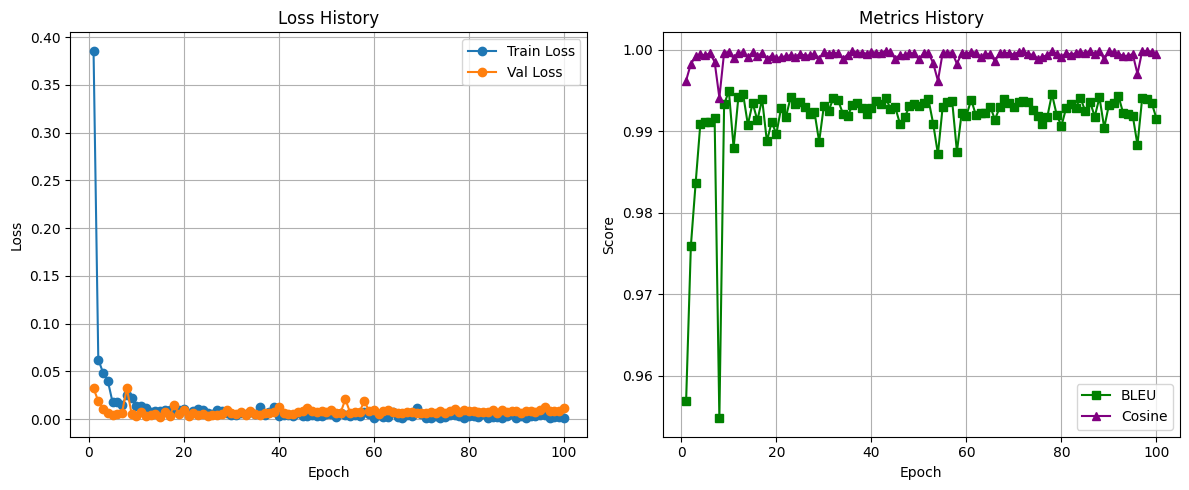


=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===
Input:  the master the sees all of truth people
Target: the master of all people sees the truth
Pred:   the master of all people sees the truth
------------------------------
Input:  the thousand river stars above bank a shine
Target: a thousand stars shine above the river bank
Pred:   a thousand stars shine above the river bank
------------------------------
Input:  the hides plant desert in hare green the
Target: the desert hare hides in the green plant
Pred:   the desert hare hides in the green plant
------------------------------
Input:  writes book truth about the scribe a the
Target: the scribe writes a book about the truth
Pred:   the scribe writes a book about the truth
------------------------------
Input:  man old finds in peace city the the
Target: the old man finds peace in the city
Pred:   the old man finds peace in the city
------------------------------
Input:  studies fire papyrus scroll light calmly scribe by
Target: scribe 

In [4]:
import torch
import random
import pandas as pd
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from transformers import (
    BartTokenizer, 
    BartForConditionalGeneration, 
    get_linear_schedule_with_warmup
)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. CONFIGURATION & DIRECTORIES
# ==========================================
MODEL_NAME = "facebook/bart-base"
MAX_LEN = 32
BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 5e-5
SAVE_DIR = "./best_model_checkpoint"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
# Assuming these variables exist in your environment. 
# Added fallbacks for script stability.

# Clean the inputs: Convert multiline strings to space-separated strings
original_shuffled = [s.replace("\n", " ").strip() for s in shuffled_sentences_raw]

# ==========================================
# 2. DATA AUGMENTATION
# ==========================================
print("Generating augmented data...")

def augment_data(ground_truth_list, num_augmentations=10):
    """
    Creates multiple shuffled versions of each ground truth sentence.
    """
    inputs = []
    targets = []
    
    for sentence in ground_truth_list:
        words = sentence.split()
        if len(words) <= 1:
            continue
            
        for _ in range(num_augmentations):
            shuffled_words = words.copy()
            random.shuffle(shuffled_words)
            inputs.append(" ".join(shuffled_words))
            targets.append(sentence)
            
    return inputs, targets

aug_inputs, aug_targets = augment_data(merged_ground_truth_sentences, num_augmentations=10)

all_inputs = aug_inputs + original_shuffled
all_targets = aug_targets + merged_ground_truth_sentences

df = pd.DataFrame({'input_text': all_inputs, 'target_text': all_targets})
print(f"Total dataset size after augmentation: {len(df)}")

# ==========================================
# 3. DATASET & DATALOADER
# ==========================================
class SentenceReconstructionDataset(Dataset):
    def __init__(self, tokenizer, data, max_len=32):
        self.tokenizer = tokenizer
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        source = str(self.data.iloc[index]['input_text'])
        target = str(self.data.iloc[index]['target_text'])

        source_tok = self.tokenizer(
            source, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        target_tok = self.tokenizer(
            target, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        # Labels for BART: shift happens internally, but we set -100 for padding
        labels = target_tok['input_ids'].flatten()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': source_tok['input_ids'].flatten(),
            'attention_mask': source_tok['attention_mask'].flatten(),
            'labels': labels
        }

# ==========================================
# 4. MODEL SETUP
# ==========================================
print(f"Loading {MODEL_NAME} model...")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Split Data
train_size = int(0.8 * len(df))
val_size = len(df) - train_size
train_indices, val_indices = random_split(range(len(df)), [train_size, val_size])

train_df = df.iloc[list(train_indices.indices)].reset_index(drop=True)
val_df = df.iloc[list(val_indices.indices)].reset_index(drop=True)

train_set = SentenceReconstructionDataset(tokenizer, train_df, max_len=MAX_LEN)
val_set = SentenceReconstructionDataset(tokenizer, val_df, max_len=MAX_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 5. METRICS HELPER
# ==========================================
try:
    from sentence_transformers import SentenceTransformer
    sim_model = SentenceTransformer('all-MiniLM-L6-v2')
    calc_cosine = True
except ImportError:
    print("sentence-transformers not installed. Cosine similarity will be skipped.")
    calc_cosine = False

def calculate_metrics(predictions, references):
    chencherry = SmoothingFunction()
    bleu_scores = [sentence_bleu([ref.split()], pred.split(), smoothing_function=chencherry.method1) 
                   for pred, ref in zip(predictions, references)]
    avg_bleu = np.mean(bleu_scores)

    avg_cosine = 0.0
    if calc_cosine:
        pred_embeddings = sim_model.encode(predictions)
        ref_embeddings = sim_model.encode(references)
        cos_sims = cosine_similarity(pred_embeddings, ref_embeddings).diagonal()
        avg_cosine = np.mean(cos_sims)
    
    return avg_bleu, avg_cosine

# ==========================================
# 6. TRAINING LOOP
# ==========================================
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'bleu': [], 'cosine': []}
best_val_loss = float('inf')

print("Starting training...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        total_train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    total_val_loss = 0
    predictions = []
    references = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            
            generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=MAX_LEN)
            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            
            # Reset -100 to pad_token_id for proper decoding
            labels_to_decode = labels.clone()
            labels_to_decode[labels_to_decode == -100] = tokenizer.pad_token_id
            decoded_labels = tokenizer.batch_decode(labels_to_decode, skip_special_tokens=True)
            
            predictions.extend(decoded_preds)
            references.extend(decoded_labels)

    avg_val_loss = total_val_loss / len(val_loader)
    bleu, cosine = calculate_metrics(predictions, references)
    
    # --- CHECKPOINTING (BEST VERSION) ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f"--> New best model found! Saving to {SAVE_DIR}...")
        # Using HuggingFace's recommended method instead of legacy torch.save
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
    
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['bleu'].append(bleu)
    history['cosine'].append(cosine)
    
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | BLEU: {bleu:.4f}")

# ==========================================
# 7. RESULTS & VISUALIZATION
# ==========================================
# Load the best model for final evaluation/visualization
print("Loading best model for final reporting...")
model = BartForConditionalGeneration.from_pretrained(SAVE_DIR).to(device)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['epoch'], history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss History')
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.legend(), plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['bleu'], label='BLEU', marker='s', color='green')
if calc_cosine:
    plt.plot(history['epoch'], history['cosine'], label='Cosine', marker='^', color='purple')
plt.title('Metrics History')
plt.xlabel('Epoch'), plt.ylabel('Score'), plt.legend(), plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===")
sample_indices = random.sample(range(len(predictions)), min(10, len(predictions)))
for i in sample_indices:
    print(f"Input:  {val_df.iloc[i]['input_text']}")
    print(f"Target: {references[i]}")
    print(f"Pred:   {predictions[i]}")
    print("-" * 30)

# Save logs
pd.DataFrame(history).to_csv('training_metrics.csv', index=False)
pd.DataFrame({'Input': val_df['input_text'], 'Target': references, 'Prediction': predictions}).to_csv('reconstruction_results.csv', index=False)
print(f"\nTraining complete. Best model saved in: {SAVE_DIR}")